In [ ]:
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

print("Import thư viện thành công!")

Import thư viện thành công!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import io

file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Đọc dữ liệu thành công!")
print("Kích thước dữ liệu:", df.shape)

df.head()

Đọc dữ liệu thành công!
Kích thước dữ liệu: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])
print("Tên các cột:")
print(df.columns.tolist())

Số dòng: 7043
Số cột: 21
Tên các cột:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [ ]:
print("Số dòng trùng lặp:", df.duplicated().sum())

Số dòng trùng lặp: 0


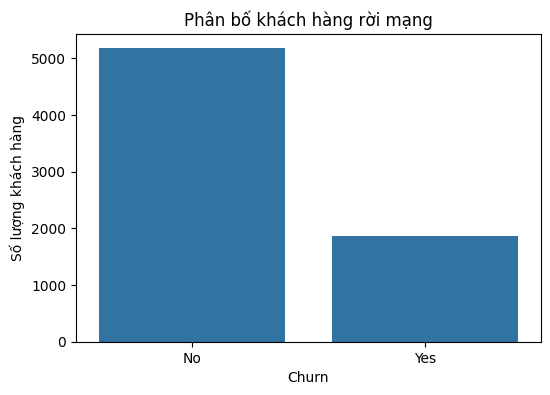

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Phân bố khách hàng rời mạng")
plt.xlabel("Churn")
plt.ylabel("Số lượng khách hàng")

plt.show()

In [ ]:
print(df["Churn"].value_counts())

print("\nTỷ lệ phần trăm:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Tỷ lệ phần trăm:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


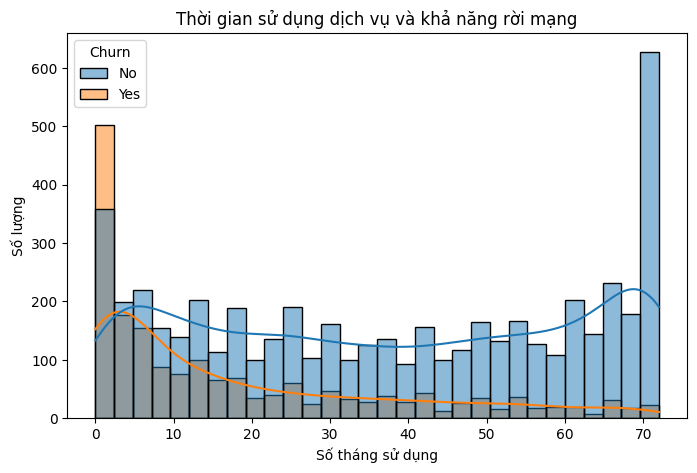

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Thời gian sử dụng dịch vụ và khả năng rời mạng")
plt.xlabel("Số tháng sử dụng")
plt.ylabel("Số lượng")

plt.show()

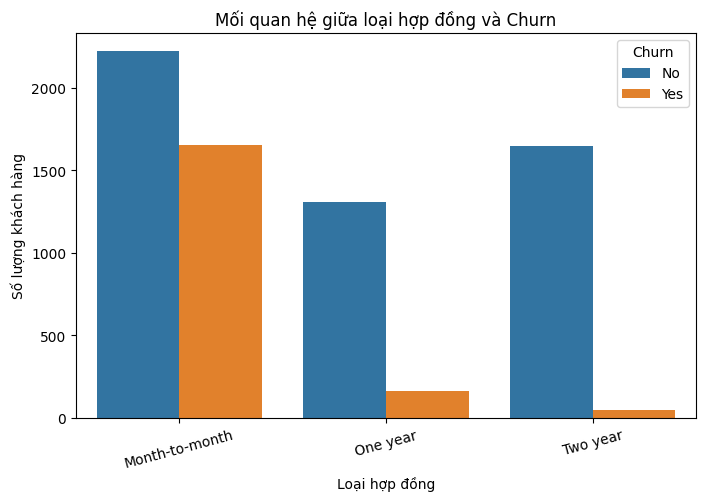

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Mối quan hệ giữa loại hợp đồng và Churn")
plt.xlabel("Loại hợp đồng")
plt.ylabel("Số lượng khách hàng")

plt.xticks(rotation=15)
plt.show()

In [ ]:
# Tạo bản sao dữ liệu
data = df.copy()

# Chuyển TotalCharges sang dạng số
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Kiểm tra giá trị thiếu
print("Giá trị thiếu trước khi xử lý:")
print(data.isnull().sum()[data.isnull().sum() > 0])

Giá trị thiếu trước khi xử lý:
TotalCharges    11
dtype: int64


In [ ]:
# Xóa các dòng thiếu TotalCharges
data = data.dropna(subset=["TotalCharges"])

# Xóa cột định danh khách hàng
data = data.drop(columns=["customerID"])

# Chuyển nhãn Churn thành 0 và 1
data["Churn"] = data["Churn"].map({
    "No": 0,
    "Yes": 1
})

print("Kích thước sau xử lý:", data.shape)
data.head()

Kích thước sau xử lý: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [ ]:
X = data.drop(columns=["Churn"])
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tập huấn luyện:", X_train.shape)
print("Tập kiểm tra:", X_test.shape)

Tập huấn luyện: (5625, 19)
Tập kiểm tra: (1407, 19)


In [ ]:
# Xác định cột dạng số và dạng chữ
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

# Bộ tiền xử lý
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Cột số:", numeric_features)
print("Cột phân loại:", categorical_features)

Cột số: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Cột phân loại: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print("Huấn luyện Logistic Regression thành công!")

Huấn luyện Logistic Regression thành công!


In [ ]:
tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )
        )
    ]
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Huấn luyện Decision Tree thành công!")

Huấn luyện Decision Tree thành công!


In [ ]:
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Không rời mạng", "Rời mạng"],
        zero_division=0
    ))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

In [ ]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_tree
    )
)

# Define and train the Random Forest model
forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

forest_model.fit(X_train, y_train)

y_pred_rf = forest_model.predict(X_test)

print("Huấn luyện Random Forest thành công!")

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)

results_df = pd.DataFrame(results)

results_df


===== Logistic Regression =====
Accuracy : 0.8038
Precision: 0.6485
Recall   : 0.5722
F1-score : 0.6080

Classification Report:
                precision    recall  f1-score   support

Không rời mạng       0.85      0.89      0.87      1033
      Rời mạng       0.65      0.57      0.61       374

      accuracy                           0.80      1407
     macro avg       0.75      0.73      0.74      1407
  weighted avg       0.80      0.80      0.80      1407


===== Decision Tree =====
Accuracy : 0.7896
Precision: 0.6021
Recall   : 0.6150
F1-score : 0.6085

Classification Report:
                precision    recall  f1-score   support

Không rời mạng       0.86      0.85      0.86      1033
      Rời mạng       0.60      0.61      0.61       374

      accuracy                           0.79      1407
     macro avg       0.73      0.73      0.73      1407
  weighted avg       0.79      0.79      0.79      1407



NameError: name 'y_pred_rf' is not defined

In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Huấn luyện Random Forest thành công!")

Huấn luyện Random Forest thành công!


In [ ]:
def evaluate_model(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n===== {name} =====")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Không rời mạng", "Rời mạng"],
        zero_division=0
    ))

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }

In [ ]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_tree
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)

results_df = pd.DataFrame(results)

results_df


===== Logistic Regression =====
Accuracy : 0.8038
Precision: 0.6485
Recall   : 0.5722
F1-score : 0.6080

Classification Report:
                precision    recall  f1-score   support

Không rời mạng       0.85      0.89      0.87      1033
      Rời mạng       0.65      0.57      0.61       374

      accuracy                           0.80      1407
     macro avg       0.75      0.73      0.74      1407
  weighted avg       0.80      0.80      0.80      1407


===== Decision Tree =====
Accuracy : 0.7896
Precision: 0.6021
Recall   : 0.6150
F1-score : 0.6085

Classification Report:
                precision    recall  f1-score   support

Không rời mạng       0.86      0.85      0.86      1033
      Rời mạng       0.60      0.61      0.61       374

      accuracy                           0.79      1407
     macro avg       0.73      0.73      0.73      1407
  weighted avg       0.79      0.79      0.79      1407


===== Random Forest =====
Accuracy : 0.7910
Precision: 0.6307
Recall 

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.803838,0.648485,0.572193,0.607955
1,Decision Tree,0.789623,0.602094,0.614973,0.608466
2,Random Forest,0.791045,0.630719,0.516043,0.567647


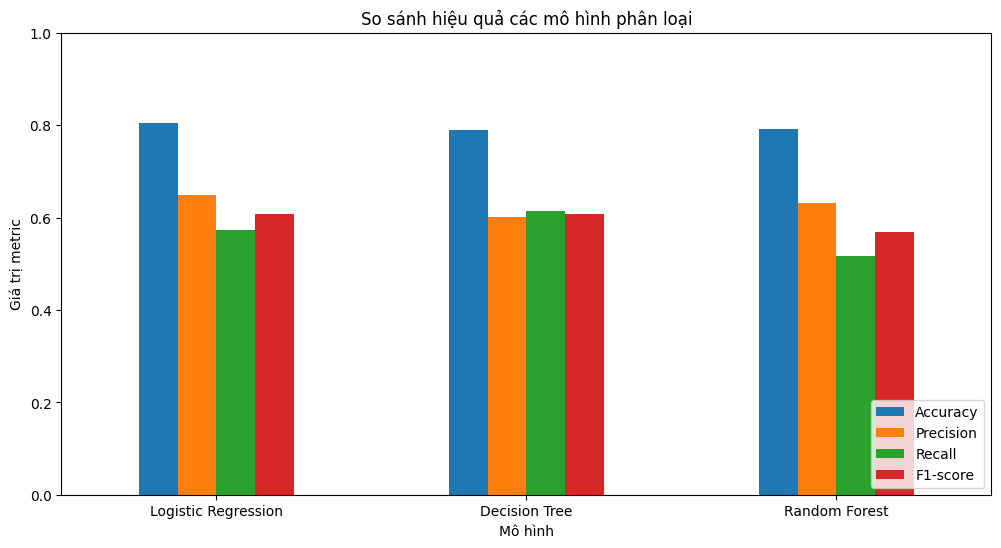

In [ ]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("So sánh hiệu quả các mô hình phân loại")
plt.xlabel("Mô hình")
plt.ylabel("Giá trị metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

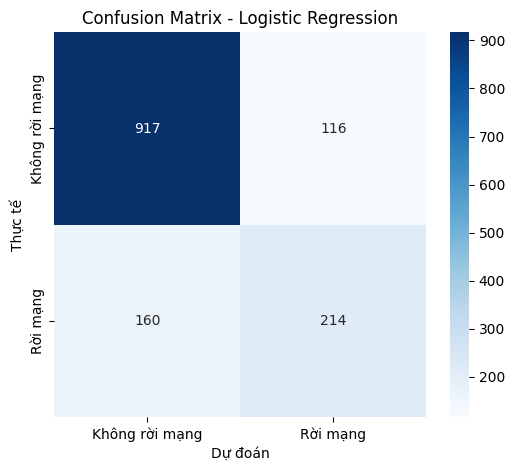

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Không rời mạng", "Rời mạng"],
    yticklabels=["Không rời mạng", "Rời mạng"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")

plt.show()

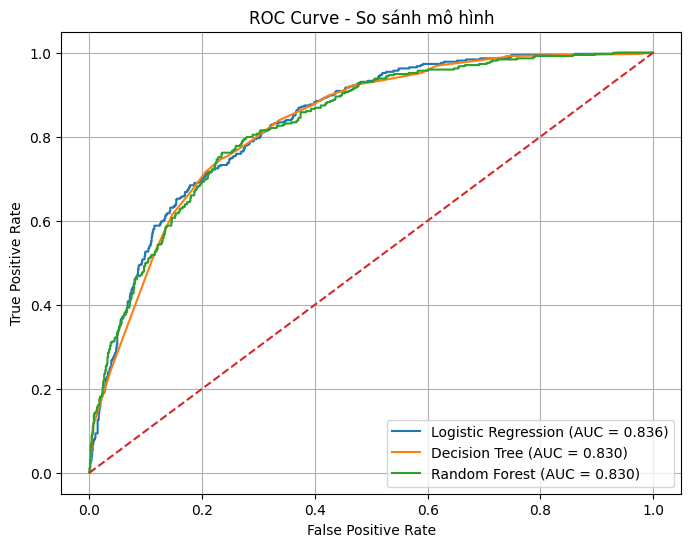

In [ ]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - So sánh mô hình")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
new_customer = pd.DataFrame([{
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 70.0,
    "TotalCharges": 140.0
}])

prediction = logistic_model.predict(new_customer)[0]
probability = logistic_model.predict_proba(new_customer)[0][1]

print("Kết quả dự đoán:")

if prediction == 1:
    print("Khách hàng có khả năng rời mạng")
else:
    print("Khách hàng có khả năng tiếp tục sử dụng dịch vụ")

print(f"Xác suất rời mạng: {probability:.2%}")

Kết quả dự đoán:
Khách hàng có khả năng rời mạng
Xác suất rời mạng: 68.69%


In [ ]:
import joblib

joblib.dump(
    logistic_model,
    "telco_churn_logistic_model.pkl"
)

print("Đã lưu mô hình!")

Đã lưu mô hình!


In [ ]:
files.download("telco_churn_logistic_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.listdir())

['.config', 'WA_Fn-UseC_-Telco-Customer-Churn (1).csv', 'telco_churn_logistic_model.pkl', 'WA_Fn-UseC_-Telco-Customer-Churn.csv', 'sample_data']


In [ ]:
from google.colab import files

files.download("telco_churn_logistic_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>